# PR05 · A brain mask defines what the analysis can see

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PP03](../../curriculum/papers/processing.md#pp03).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** How can an incorrect brain boundary alter the inputs and evaluation of a segmentation method?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Distinguish extraction from tissue classification.
- Inspect omission and inclusion errors separately.
- See how simple thresholding fails even in a controlled image.

## Understand the operation

Brain extraction marks the voxels intended to represent intracranial brain content, removing surrounding structures for subsequent steps. The exact inclusion convention may differ across tools, particularly near CSF and boundaries. It is not the same operation as separating gray matter from white matter. Removing a voxel at this stage can prevent later software from recovering its signal; including skull or dura can bias registration, intensity estimation and surfaces.

A threshold is not an anatomical model. Skull and other non-brain tissue can be bright, while fluid or artifact-affected parts of the brain can be dark. Connected components and hole filling provide useful concepts but are not substitutes for a validated extraction algorithm. Their behavior depends on seeds, connectivity and topology. A lesion, resection or severe atrophy can violate a simple shape assumption.

Our constructed image contains a bright exterior ring, a moderate-brightness brain disk and a dark central cavity that our stated target mask includes. Thresholding selects the ring and misses the cavity. Choosing the connected component containing a known interior seed and filling its enclosed hole recovers this deliberately simple target. We know where to seed only because we designed the image. In actual MRI, inspect several planes and thin cortical edges, cerebellum and inferior brain. An attractive central slice may conceal substantial failures elsewhere. A failed extraction can require upstream bias correction, different acquisition-appropriate settings or an explicitly reviewed alternative.

## Transformation contract

**Input:** intensity image and target-mask definition. **Output:** Boolean mask and masked image. **Preserved:** values inside retained voxels. **Lost:** excluded values if only the masked derivative is kept; retain originals. **QC:** false inclusion, false omission, and boundary overlays, not only total mask volume.


## Read the actual course material

- [Oxford FSL: Structural Analysis practical](https://pages.fmrib.ox.ac.uk/fslcourse/practicals/seg_struc/index.html). Public university practical; linked only.
- [fMRIPrep: pipeline details](https://fmriprep.org/en/stable/workflows.html). Official project documentation; linked only.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Explain thresholding, connected components and hole filling as separate operations. Count omitted target voxels and included exterior voxels. Use only the known toy seed; do not describe this as BET, HD-BET or brain extraction suitable for patients. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
from scipy.ndimage import label,binary_fill_holes
import matplotlib.pyplot as plt
r,c=np.mgrid[:81,:81]; radius=np.hypot(r-40,c-40)
truth=radius<=27; skull=(radius>=32)&(radius<=36)
image=np.zeros((81,81)); image[truth]=60; image[radius<7]=20; image[skull]=110
threshold=image>40
components,n=label(threshold); chosen=components[40,55]
mask=binary_fill_holes(components==chosen)
false_positive=np.count_nonzero(threshold & ~truth)
false_negative=np.count_nonzero(~threshold & truth)
print('threshold inclusion/omission:',false_positive,false_negative,'components:',n)
assert false_positive>0 and false_negative>0
assert np.array_equal(mask,truth)


threshold inclusion/omission: 848 145 components: 2


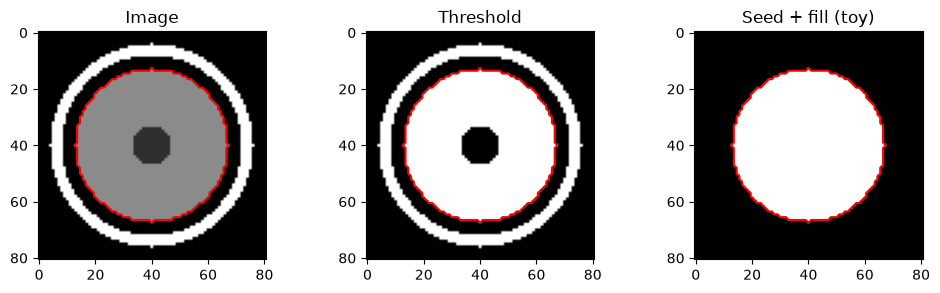

Wrong seed selects skull; a component ID is not an anatomical label.


In [2]:
fig,axes=plt.subplots(1,3,figsize=(10,3))
for ax,array,name in zip(axes,[image,threshold,mask],['Image','Threshold','Seed + fill (toy)']):
    ax.imshow(array,cmap='gray'); ax.contour(truth,[.5],colors='red'); ax.set_title(name)
plt.tight_layout(); plt.show()
wrong_component=components==components[40,74]
assert np.any(wrong_component & skull) and not np.any(wrong_component & truth)
print('Wrong seed selects skull; a component ID is not an anatomical label.')


## Check and explain

Thresholding has nonzero false inclusions and omissions. The chosen-seed mask equals the stated synthetic target exactly. A seed in the exterior ring selects the wrong structure, demonstrating that the software cannot infer what the integer component ID means.

## Deliberately wrong method

Using the bright ring or treating the largest/first component as automatically “brain” turns a numerical rule into an unsupported anatomical assertion. Filling holes may include truly absent tissue in other settings; the target definition matters.

## Transfer to an actual dataset or tool — guided assignment

Use Oxford’s BET preparation exercise before FAST. Run two documented extraction settings on the course anatomical image, retain both outputs and compare boundary contours in sagittal, coronal and axial views. Count mask volume but also record specific false inclusion/omission locations. The source course data are educational-use resources obtained separately; no subject image is included here. Submit a reasoned choice or an unresolved QC flag rather than selecting by volume alone.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Is extraction tissue segmentation? **Answer:** no; a brain mask defines included territory while tissue segmentation classifies its contents.
2. Why keep the unmasked source? **Answer:** an omission cannot be diagnosed or reversed from a masked derivative alone.


### Return to the research question

Reopen [PP03](../../curriculum/papers/processing.md#pp03) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
